## Task 2: Decision Trees for Classification
**Dataset:** Iris Dataset (Local File)

### 1. Load and Preprocess the Dataset
Loading the Iris dataset from our local directory. We will separate the features from the target species. If an 'Id' column exists, it will be removed as it does not contribute to the model.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score

# Load the local Iris dataset (make sure the extension is correct: .csv or .xlsx)
df_iris = pd.read_csv(r'D:\AI\Ai_intern\Data Set For Task\1) iris.csv') 

# Drop 'Id' column if it exists in the dataset
if 'Id' in df_iris.columns:
    df_iris = df_iris.drop('Id', axis=1)

# Assume the target column is the last column in the dataset
target_col = df_iris.columns[-1]

# Separate features (X) and target (y)
X_iris = df_iris.drop(target_col, axis=1)
y_iris = df_iris[target_col]

# Split the data into training (80%) and testing (20%) sets
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train_dt.shape}")

Training data shape: (120, 4)


### 2. Hyperparameter Tuning: Finding Optimal `max_depth` and `criterion`
To build the most robust model, we will use nested loops to test combinations of maximum tree depth (`max_depth`) and splitting criteria (`gini` vs. `entropy`). This ensures we find the optimal hyperparameters that yield the highest accuracy on the test set.

In [18]:
# Initialize variables to track the best parameters and performance
best_accuracy = 0
best_depth = 1
best_criterion = 'gini'

depth_range = range(1, 11) # Testing tree depths from 1 to 10
criteria_options = ['gini', 'entropy'] # Testing both splitting criteria

# Loop through each combination of criterion and depth
for criterion in criteria_options:
    for depth in depth_range:
        # Initialize and train the model with current parameters
        temp_tree = DecisionTreeClassifier(max_depth=depth, criterion=criterion, random_state=42)
        temp_tree.fit(X_train_dt, y_train_dt)
        
        # Predict and calculate accuracy on the test set
        temp_pred = temp_tree.predict(X_test_dt)
        temp_acc = accuracy_score(y_test_dt, temp_pred)
        
        # Update the best parameters if current accuracy is strictly higher
        if temp_acc > best_accuracy:
            best_accuracy = temp_acc
            best_depth = depth
            best_criterion = criterion

print(f"Optimal max_depth found: {best_depth}")
print(f"Optimal criterion found: '{best_criterion}'")
print(f"Highest Accuracy achieved during tuning: {best_accuracy:.4f}")

Optimal max_depth found: 3
Optimal criterion found: 'gini'
Highest Accuracy achieved during tuning: 1.0000


### 3. Train and Evaluate Final Model (Comparison)
Using the optimal hyperparameters discovered during tuning (`max_depth=3`, `criterion='gini'`), we train the final model. Additionally, we train a second comparison model holding the same optimal depth (`best_depth=3`) but using the alternative criterion (`criterion='entropy'`). We evaluate both models on Accuracy and F1-Score.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Train the final optimal model using the best parameters found by the loop
tree_model = DecisionTreeClassifier(max_depth=best_depth, criterion=best_criterion, random_state=42)
tree_model.fit(X_train_dt, y_train_dt)

# Define alternative criterion and train comparison model
alt_criterion = 'entropy' if best_criterion == 'gini' else 'gini'
tree_model_alt = DecisionTreeClassifier(max_depth=best_depth, criterion=alt_criterion, random_state=42)
tree_model_alt.fit(X_train_dt, y_train_dt)

# Make predictions and calculate metrics for both
y_pred_dt = tree_model.predict(X_test_dt)
acc_dt = accuracy_score(y_test_dt, y_pred_dt)
f1_dt = f1_score(y_test_dt, y_pred_dt, average='weighted')

y_pred_alt = tree_model_alt.predict(X_test_dt)
acc_alt = accuracy_score(y_test_dt, y_pred_alt)
f1_alt = f1_score(y_test_dt, y_pred_alt, average='weighted')

print(f"--- Optimal Model: {best_criterion.capitalize()} Criterion (max_depth={best_depth}) ---")
print(f"Accuracy: {acc_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}\n")

print(f"--- Reference Model: {alt_criterion.capitalize()} Criterion (max_depth={best_depth}) ---")
print(f"Accuracy: {acc_alt:.4f}")
print(f"F1-Score: {f1_alt:.4f}")

--- Optimal Model: Gini Criterion (max_depth=3) ---
Accuracy: 1.0000
F1-Score: 1.0000

--- Reference Model: Entropy Criterion (max_depth=3) ---
Accuracy: 1.0000
F1-Score: 1.0000


### 4. Visualizing Criterion Impact: Gini vs. Entropy
We are visualizing both the optimal and reference decision trees side-by-side, holding the `max_depth` constant at the optimal depth (`best_depth=3`) found during tuning. This allows a direct visual comparison of how the two mathematical splitting criteria (`gini` vs. `entropy`) make decisions.

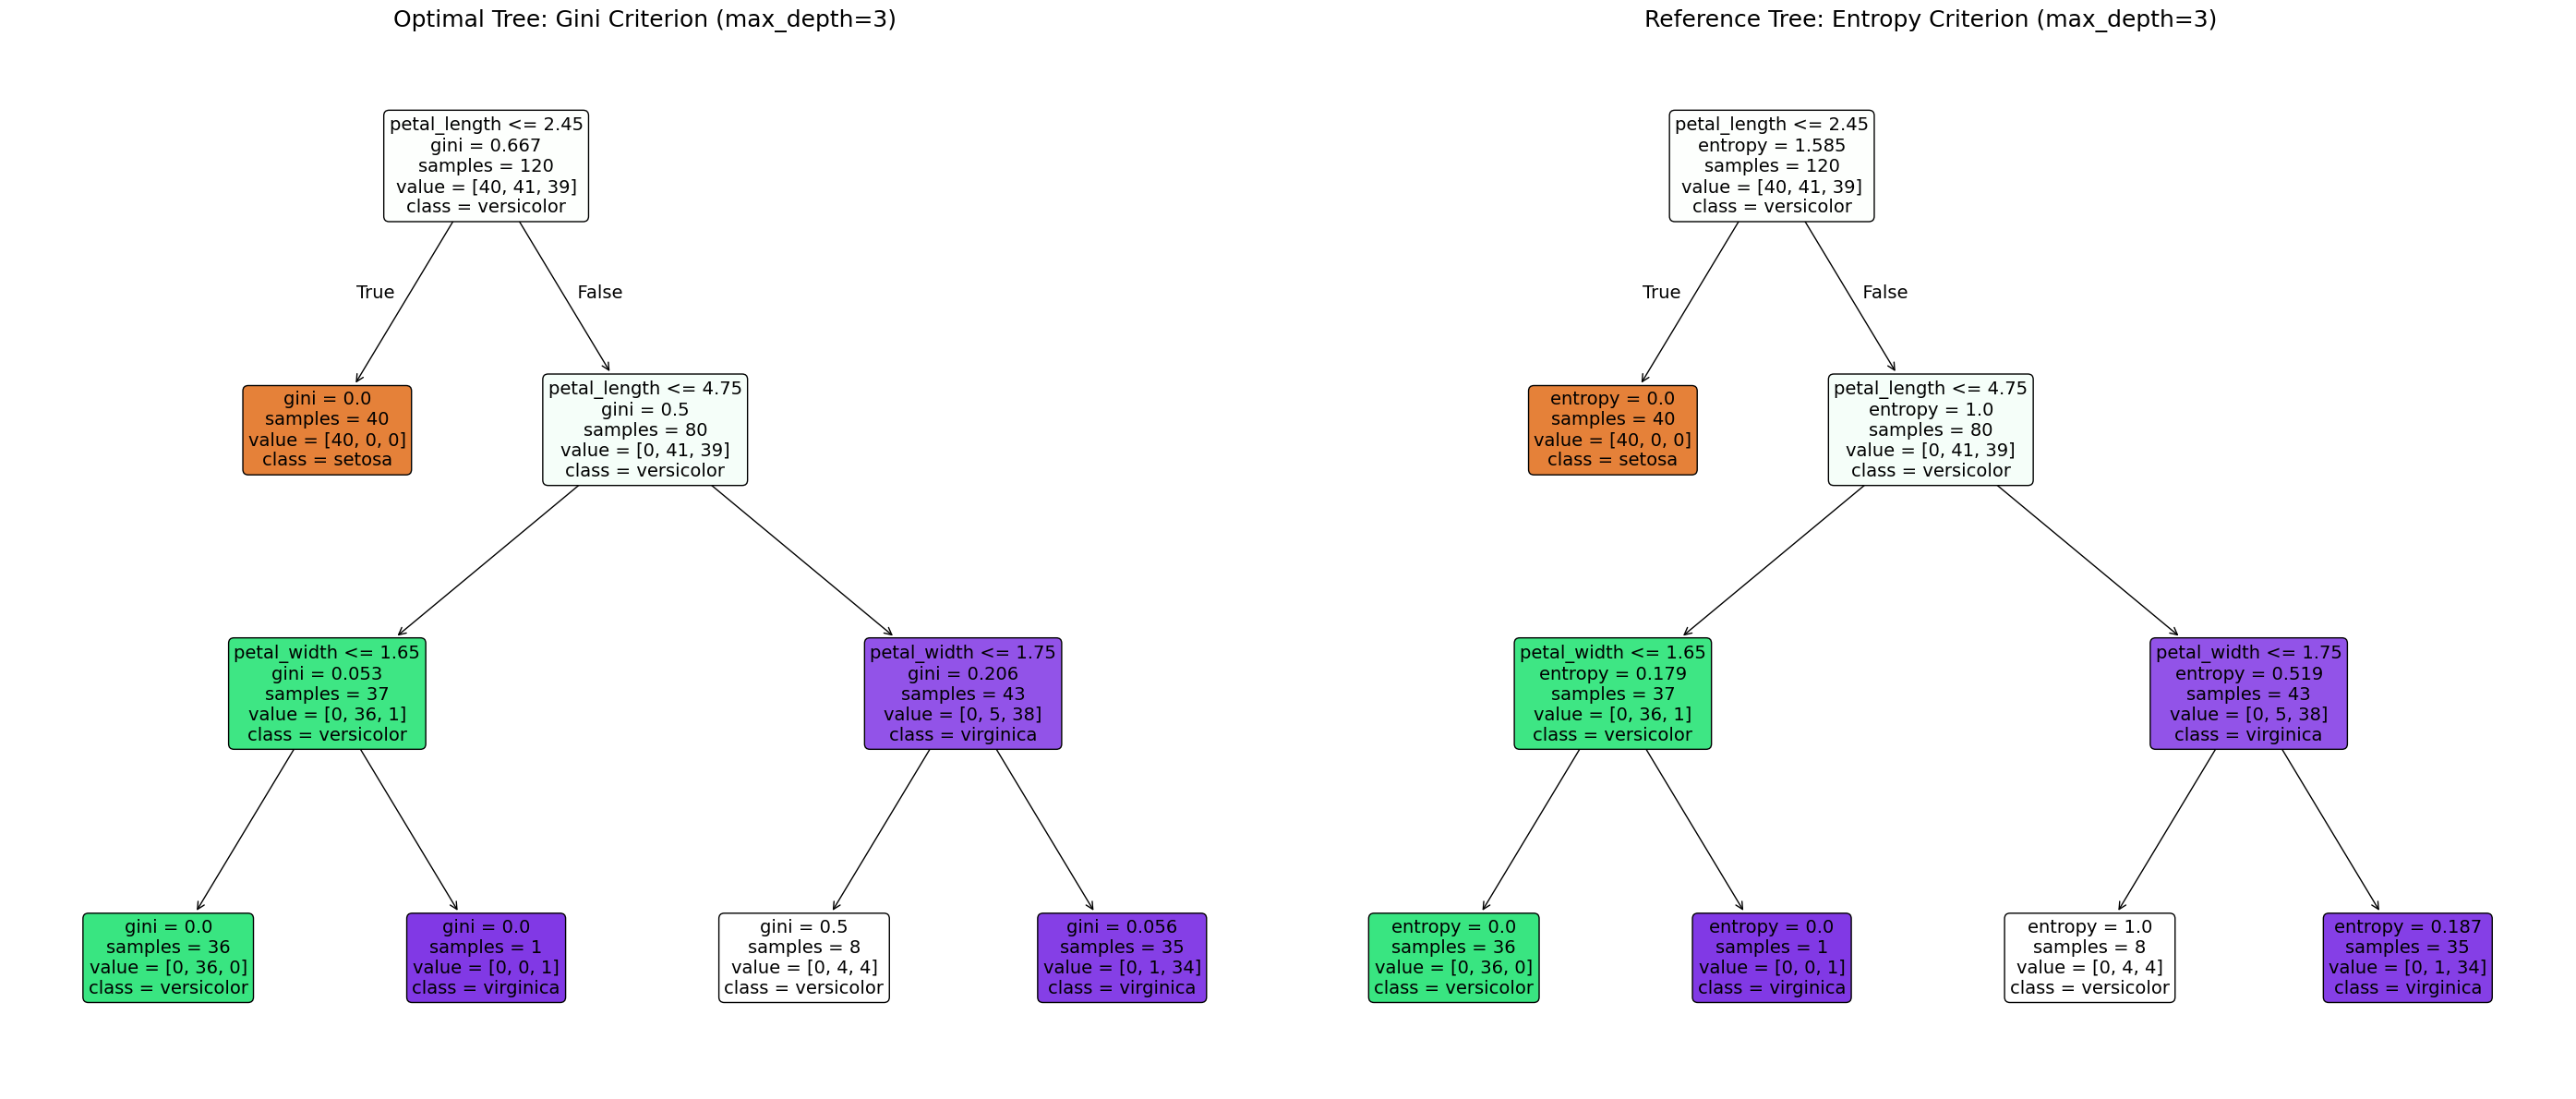

In [20]:
# Get unique class names from the target column and feature names
unique_classes = y_iris.unique().astype(str).tolist()
feature_names_list = X_iris.columns.tolist()

# Set up the figure for side-by-side plots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(28, 12))

# Plot Optimal Tree
plot_tree(
    tree_model, 
    feature_names=feature_names_list, 
    class_names=unique_classes, 
    filled=True, 
    rounded=True,
    fontsize=14,
    ax=axes[0]
)
axes[0].set_title(f"Optimal Tree: {best_criterion.capitalize()} Criterion (max_depth={best_depth})", fontsize=18)

# Plot Reference Tree
plot_tree(
    tree_model_alt, 
    feature_names=feature_names_list, 
    class_names=unique_classes, 
    filled=True, 
    rounded=True,
    fontsize=14,
    ax=axes[1]
)
axes[1].set_title(f"Reference Tree: {alt_criterion.capitalize()} Criterion (max_depth={best_depth})", fontsize=18)

plt.tight_layout()
plt.show()